# AUPRC curve (100:1:1) - 4 ensemble strategies + best model

Notebook nay se:
- Load embeddings ratio 100:1:1 (theo naming hien tai: test_10_1_1 / gtex_test_10_1_1)
- Chay inference cho 4 ensemble strategy: 1_1_1, 2_1_1, 4_1_1, 9_1_1 (soft-voting qua set_1..set_10)
- Chay inference cho 2 best model do ban chi dinh (GENCODE set_4, GTEx set_2)
- Ve PR-AUPRC curve macro cho GENCODE va GTEx
- Export ket qua inference dung cho bai toan 3 lop: y_true + y_prob + class_order (+ one-vs-rest)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
torch.manual_seed(42)

In [2]:
# ===== Paths =====
ROOT = r"D:\\Bio_sequence_Research_AITALAB"
VIS_DIR = os.path.join(ROOT, "benchmark", "task1_splicing_prediction", "Visualization")
TRAIN_VAL_DIR = os.path.join(ROOT, "train", "task1_splicing_prediction", "data_preparation", "train_val")
EXP7_DIR = os.path.join(ROOT, "train", "task1_splicing_prediction", "training", "trained_models", "experiment_7")

# Best models provided by user
BEST_GENCODE_CKPT = r"D:\\Bio_sequence_Research_AITALAB\\train\\task1_splicing_prediction\\training\\trained_models\\experiment_7\\9_1_1\\set_4\\best_model.pt"
BEST_GTEX_CKPT = r"D:\\Bio_sequence_Research_AITALAB\\train\\task1_splicing_prediction\\training\\trained_models\\experiment_7\\9_1_1\\set_2\\best_model.pt"

# Model config from training/config.py and experiment_7/config.json
HIDDEN_DIMS = [512, 256]
DROPOUT = 0.3
NUM_CLASSES = 3
BATCH_SIZE = 4096

# Export options for multiclass inference artifacts
EXPORT_OVR = True

ENSEMBLE_STRATEGIES = ["1_1_1", "2_1_1", "4_1_1", "9_1_1"]
SET_NAMES = [f"set_{i}" for i in range(1, 11)]
INCLUDE_ENSEMBLE_ALL_40 = True

os.makedirs(VIS_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("VIS_DIR:", VIS_DIR)
print("NUM_CLASSES:", NUM_CLASSES)
print("EXPORT_OVR:", EXPORT_OVR)
print("INCLUDE_ENSEMBLE_ALL_40:", INCLUDE_ENSEMBLE_ALL_40)

Device: cuda
VIS_DIR: D:\\Bio_sequence_Research_AITALAB\benchmark\task1_splicing_prediction\Visualization
NUM_CLASSES: 3
EXPORT_OVR: True
INCLUDE_ENSEMBLE_ALL_40: True


In [3]:
class SpliceSiteClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dims, dropout, num_classes):
        super().__init__()
        layers = []
        prev_dim = embedding_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, embeddings):
        return self.classifier(embeddings)


def resolve_embedding_path(base_dir, candidates):
    for c in candidates:
        p = os.path.join(base_dir, c)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Cannot find any embedding file in candidates: {candidates}")


def load_embedding_pt(pt_path):
    data = torch.load(pt_path, map_location="cpu")
    embeddings = data["embeddings"].float()
    labels = data["labels"].long()
    return embeddings, labels


def build_model(embedding_dim):
    return SpliceSiteClassifier(
        embedding_dim=embedding_dim,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        num_classes=NUM_CLASSES,
    ).to(device)


def load_checkpoint_into_model(model, ckpt_path):
    state = torch.load(ckpt_path, map_location=device)
    try:
        model.load_state_dict(state)
        return model
    except Exception:
        if hasattr(state, "to"):
            return state.to(device)
        raise RuntimeError(f"Unsupported checkpoint format: {ckpt_path}")


@torch.no_grad()
def infer_probs(model, embeddings, labels, batch_size=BATCH_SIZE):
    model.eval()
    ds = TensorDataset(embeddings, labels)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    all_probs = []
    all_labels = []

    for emb, y in loader:
        emb = emb.to(device)
        logits = model(emb)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)
    return y_true, y_prob


def macro_pr_curve(y_true, y_prob, n_classes=3, grid_size=1000):
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))

    recall_grid = np.linspace(0.0, 1.0, grid_size)
    precision_interp = []

    for c in range(n_classes):
        precision_c, recall_c, _ = precision_recall_curve(y_bin[:, c], y_prob[:, c])
        order = np.argsort(recall_c)
        rc = recall_c[order]
        pc = precision_c[order]

        # Remove duplicate recalls to keep np.interp stable
        rc_unique, idx = np.unique(rc, return_index=True)
        pc_unique = pc[idx]

        if len(rc_unique) == 1:
            p_interp = np.full_like(recall_grid, fill_value=pc_unique[0], dtype=float)
        else:
            p_interp = np.interp(recall_grid, rc_unique, pc_unique)

        precision_interp.append(p_interp)

    precision_macro = np.mean(np.stack(precision_interp, axis=0), axis=0)
    auprc_macro = average_precision_score(y_bin, y_prob, average="macro")
    return recall_grid, precision_macro, float(auprc_macro)


def run_ensemble_strategy(dataset_embeddings, dataset_labels, strategy):
    probs_list = []
    used_sets = []

    for set_name in SET_NAMES:
        ckpt = os.path.join(EXP7_DIR, strategy, set_name, "best_model.pt")
        if not os.path.exists(ckpt):
            continue

        model = build_model(dataset_embeddings.shape[1])
        model = load_checkpoint_into_model(model, ckpt)
        y_true_i, y_prob_i = infer_probs(model, dataset_embeddings, dataset_labels, batch_size=BATCH_SIZE)

        if len(probs_list) == 0:
            y_true_ref = y_true_i
        else:
            if not np.array_equal(y_true_ref, y_true_i):
                raise ValueError(f"Label mismatch across ensemble members in strategy {strategy}")

        probs_list.append(y_prob_i)
        used_sets.append(set_name)

    if len(probs_list) == 0:
        raise RuntimeError(f"No checkpoint found for strategy={strategy}")

    y_prob_ensemble = np.mean(np.stack(probs_list, axis=0), axis=0)
    return y_true_ref, y_prob_ensemble, used_sets


def run_ensemble_all_40(dataset_embeddings, dataset_labels):
    probs_list = []
    used_members = []
    y_true_ref = None

    for strategy in ENSEMBLE_STRATEGIES:
        for set_name in SET_NAMES:
            ckpt = os.path.join(EXP7_DIR, strategy, set_name, "best_model.pt")
            if not os.path.exists(ckpt):
                continue

            model = build_model(dataset_embeddings.shape[1])
            model = load_checkpoint_into_model(model, ckpt)
            y_true_i, y_prob_i = infer_probs(model, dataset_embeddings, dataset_labels, batch_size=BATCH_SIZE)

            if y_true_ref is None:
                y_true_ref = y_true_i
            else:
                if not np.array_equal(y_true_ref, y_true_i):
                    raise ValueError("Label mismatch across members in Ensemble_All_40")

            probs_list.append(y_prob_i)
            used_members.append(f"{strategy}/{set_name}")

    if len(probs_list) == 0:
        raise RuntimeError("No checkpoint found for Ensemble_All_40")

    y_prob_ensemble = np.mean(np.stack(probs_list, axis=0), axis=0)
    return y_true_ref, y_prob_ensemble, used_members


def run_best_model(dataset_embeddings, dataset_labels, ckpt_path):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
    model = build_model(dataset_embeddings.shape[1])
    model = load_checkpoint_into_model(model, ckpt_path)
    return infer_probs(model, dataset_embeddings, dataset_labels, batch_size=BATCH_SIZE)

In [4]:
# Resolve embedding files for ratio 100:1:1 (current naming in pipeline often uses 10_1_1)
gencode_emb_path = resolve_embedding_path(
    TRAIN_VAL_DIR,
    [
        "test_data_embeddings.pt",
    ],
)
gtex_emb_path = resolve_embedding_path(
    TRAIN_VAL_DIR,
    [
        "gtex_test_data_embeddings.pt",
    ],
)

print("GENCODE embeddings:", gencode_emb_path)
print("GTEx embeddings:", gtex_emb_path)

gencode_emb, gencode_labels = load_embedding_pt(gencode_emb_path)
gtex_emb, gtex_labels = load_embedding_pt(gtex_emb_path)

print("GENCODE shape:", tuple(gencode_emb.shape), "labels:", tuple(gencode_labels.shape))
print("GTEx shape:", tuple(gtex_emb.shape), "labels:", tuple(gtex_labels.shape))

GENCODE embeddings: D:\\Bio_sequence_Research_AITALAB\train\task1_splicing_prediction\data_preparation\train_val\test_data_embeddings.pt
GTEx embeddings: D:\\Bio_sequence_Research_AITALAB\train\task1_splicing_prediction\data_preparation\train_val\gtex_test_data_embeddings.pt
GENCODE shape: (938297, 1280) labels: (938297,)
GTEx shape: (1402857, 1280) labels: (1402857,)


In [5]:
results = {
    "GENCODE": {},
    "GTEx": {},
}

# ----- Ensemble strategies -----
for strategy in ENSEMBLE_STRATEGIES:
    # GENCODE
    y_true_g, y_prob_g, used_sets_g = run_ensemble_strategy(gencode_emb, gencode_labels, strategy)
    rec_g, pre_g, auprc_g = macro_pr_curve(y_true_g, y_prob_g, n_classes=NUM_CLASSES)
    results["GENCODE"][f"Ensemble_{strategy}"] = {
        "recall": rec_g,
        "precision": pre_g,
        "auprc_macro": auprc_g,
        "used_sets": used_sets_g,
        "y_true": y_true_g,
        "y_prob": y_prob_g,
    }

    # GTEx
    y_true_t, y_prob_t, used_sets_t = run_ensemble_strategy(gtex_emb, gtex_labels, strategy)
    rec_t, pre_t, auprc_t = macro_pr_curve(y_true_t, y_prob_t, n_classes=NUM_CLASSES)
    results["GTEx"][f"Ensemble_{strategy}"] = {
        "recall": rec_t,
        "precision": pre_t,
        "auprc_macro": auprc_t,
        "used_sets": used_sets_t,
        "y_true": y_true_t,
        "y_prob": y_prob_t,
    }

# ----- Ensemble all 40 models -----
if INCLUDE_ENSEMBLE_ALL_40:
    y_true_g40, y_prob_g40, used_g40 = run_ensemble_all_40(gencode_emb, gencode_labels)
    rec_g40, pre_g40, auprc_g40 = macro_pr_curve(y_true_g40, y_prob_g40, n_classes=NUM_CLASSES)
    results["GENCODE"]["Ensemble_All_40"] = {
        "recall": rec_g40,
        "precision": pre_g40,
        "auprc_macro": auprc_g40,
        "used_sets": used_g40,
        "y_true": y_true_g40,
        "y_prob": y_prob_g40,
    }

    y_true_t40, y_prob_t40, used_t40 = run_ensemble_all_40(gtex_emb, gtex_labels)
    rec_t40, pre_t40, auprc_t40 = macro_pr_curve(y_true_t40, y_prob_t40, n_classes=NUM_CLASSES)
    results["GTEx"]["Ensemble_All_40"] = {
        "recall": rec_t40,
        "precision": pre_t40,
        "auprc_macro": auprc_t40,
        "used_sets": used_t40,
        "y_true": y_true_t40,
        "y_prob": y_prob_t40,
    }

# ----- User-provided best models -----
y_true_bg, y_prob_bg = run_best_model(gencode_emb, gencode_labels, BEST_GENCODE_CKPT)
rec_bg, pre_bg, auprc_bg = macro_pr_curve(y_true_bg, y_prob_bg, n_classes=NUM_CLASSES)
results["GENCODE"]["BestModel_set_4_ratio_9_1_1"] = {
    "recall": rec_bg,
    "precision": pre_bg,
    "auprc_macro": auprc_bg,
    "checkpoint": BEST_GENCODE_CKPT,
    "y_true": y_true_bg,
    "y_prob": y_prob_bg,
}

y_true_bt, y_prob_bt = run_best_model(gtex_emb, gtex_labels, BEST_GTEX_CKPT)
rec_bt, pre_bt, auprc_bt = macro_pr_curve(y_true_bt, y_prob_bt, n_classes=NUM_CLASSES)
results["GTEx"]["BestModel_set_2_ratio_9_1_1"] = {
    "recall": rec_bt,
    "precision": pre_bt,
    "auprc_macro": auprc_bt,
    "checkpoint": BEST_GTEX_CKPT,
    "y_true": y_true_bt,
    "y_prob": y_prob_bt,
}

print("Done inference + PR computation.")

Done inference + PR computation.


In [6]:
# Summary table
rows = []
for dataset_name, methods in results.items():
    for method_name, payload in methods.items():
        rows.append({
            "dataset": dataset_name,
            "method": method_name,
            "auprc_macro": payload["auprc_macro"],
        })

summary_df = pd.DataFrame(rows).sort_values(["dataset", "auprc_macro"], ascending=[True, False]).reset_index(drop=True)
summary_df

,dataset,method,auprc_macro
0,GENCODE,Ensemble_4_1_1,0.796714
1,GENCODE,Ensemble_9_1_1,0.796200
2,GENCODE,Ensemble_All_40,0.795921
3,GENCODE,Ensemble_2_1_1,0.790701
4,GENCODE,BestModel_set_4_ratio_9_1_1,0.784542
5,GENCODE,Ensemble_1_1_1,0.781628
6,GTEx,Ensemble_4_1_1,0.766554
7,GTEx,Ensemble_All_40,0.765837
8,GTEx,Ensemble_9_1_1,0.765437
9,GTEx,Ensemble_2_1_1,0.761405


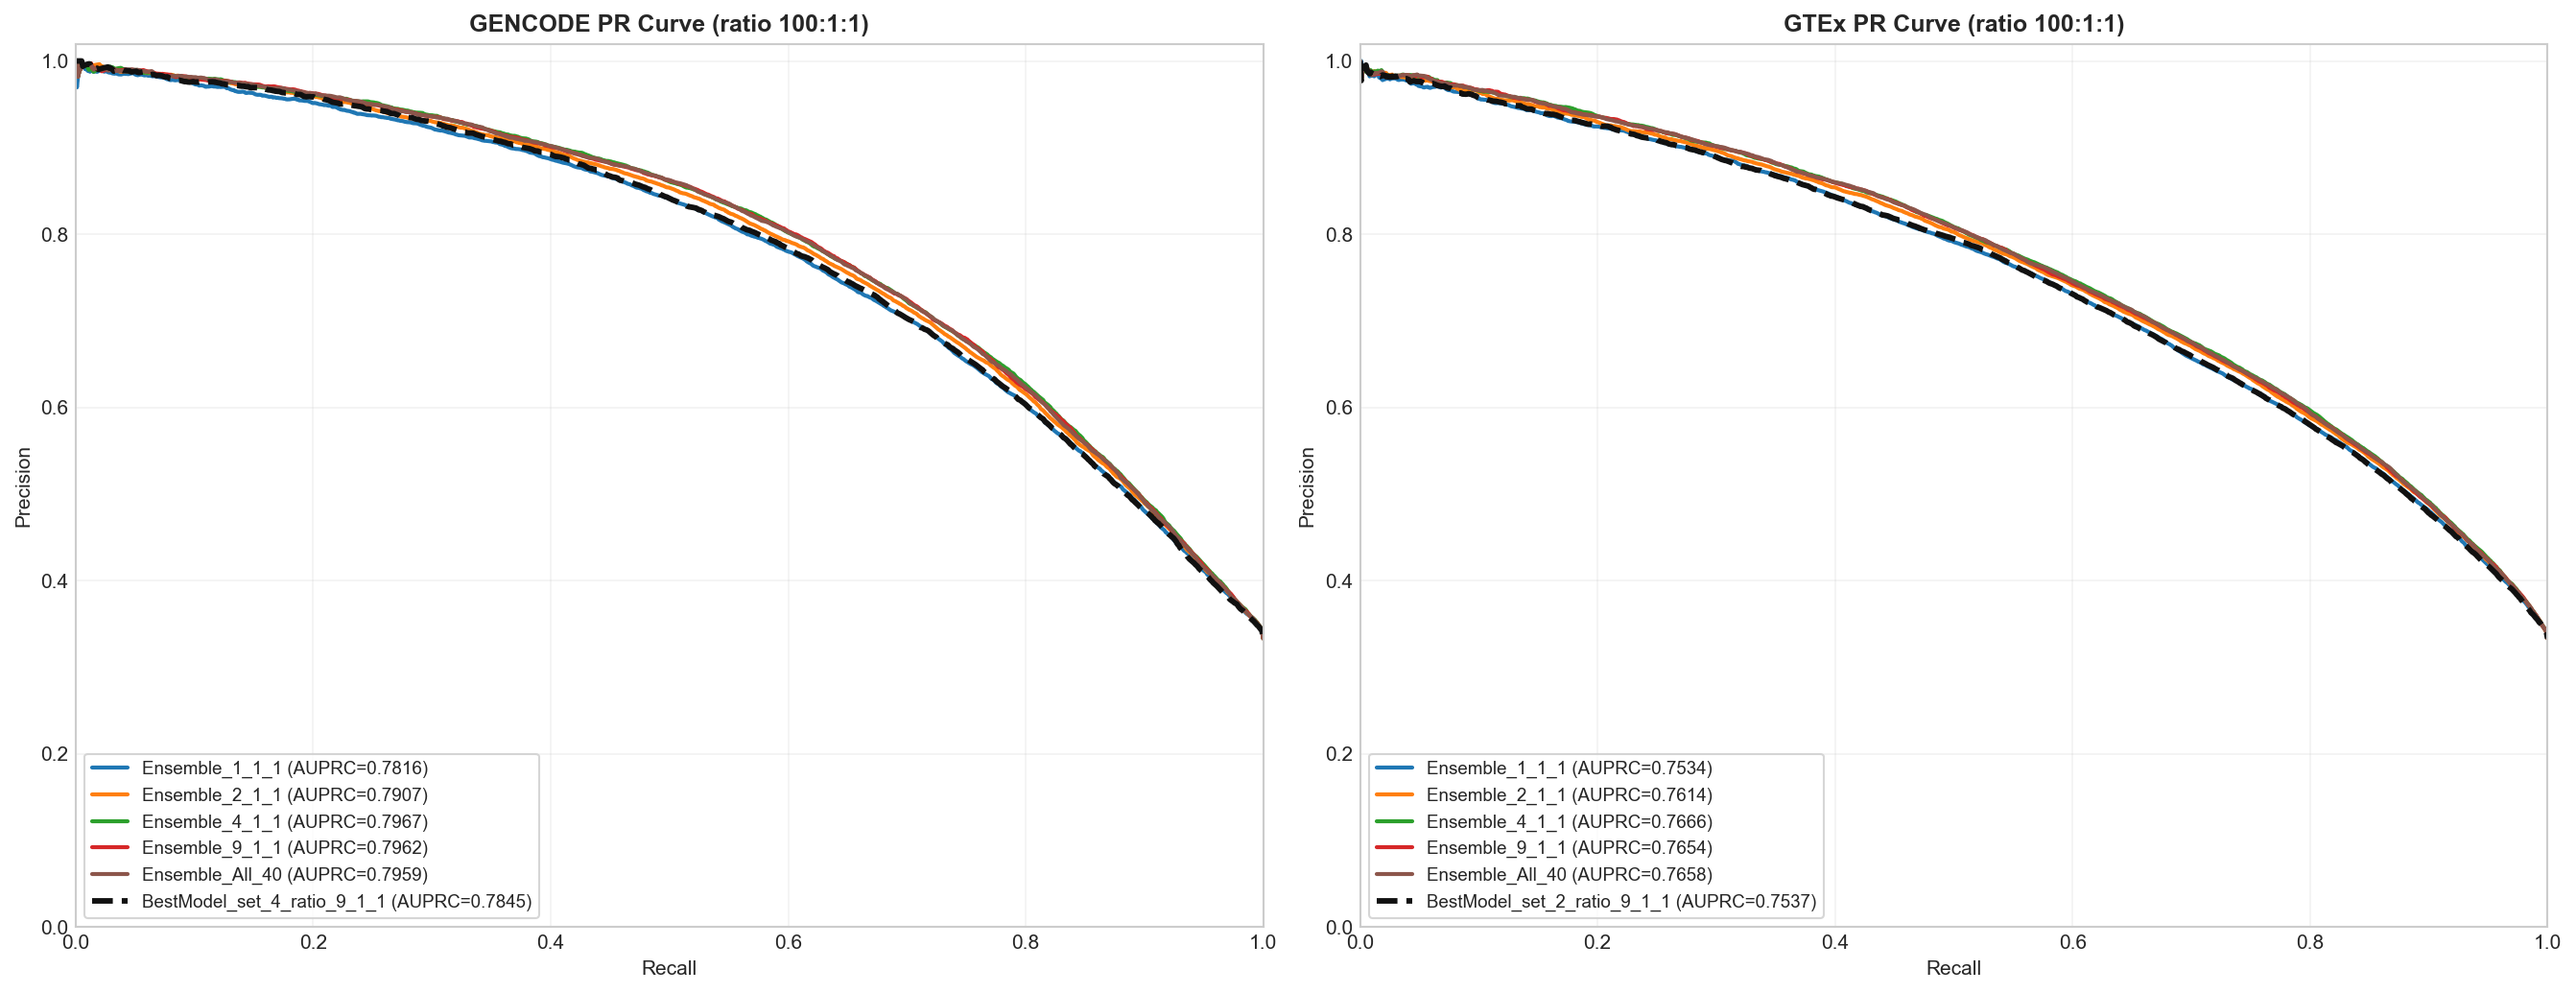

Saved: D:\\Bio_sequence_Research_AITALAB\benchmark\task1_splicing_prediction\Visualization\AUPRC_curve_100_1_1_ensemble_best_GENCODE_GTEx.png


In [7]:
def plot_dataset_pr(ax, dataset_name, methods_dict):
    colors = {
        "Ensemble_1_1_1": "#1f77b4",
        "Ensemble_2_1_1": "#ff7f0e",
        "Ensemble_4_1_1": "#2ca02c",
        "Ensemble_9_1_1": "#d62728",
        "Ensemble_All_40": "#8c564b",
    }

    for method_name, payload in methods_dict.items():
        recall = payload["recall"]
        precision = payload["precision"]
        auprc = payload["auprc_macro"]

        if method_name.startswith("BestModel"):
            c = "#111111"
            ls = "--"
            lw = 2.8
        else:
            c = colors.get(method_name, None)
            ls = "-"
            lw = 2.0

        ax.plot(recall, precision, linestyle=ls, linewidth=lw, color=c,
                label=f"{method_name} (AUPRC={auprc:.4f})")

    ax.set_title(f"{dataset_name} PR Curve (ratio 100:1:1)", fontsize=12, weight="bold")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower left", fontsize=9, frameon=True)


fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
plot_dataset_pr(axes[0], "GENCODE", results["GENCODE"])
plot_dataset_pr(axes[1], "GTEx", results["GTEx"])
plt.tight_layout()

combined_png = os.path.join(VIS_DIR, "AUPRC_curve_100_1_1_ensemble_best_GENCODE_GTEx.png")
plt.savefig(combined_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", combined_png)

In [8]:
# Save summary and compact JSON report
summary_csv = os.path.join(VIS_DIR, "AUPRC_curve_100_1_1_summary.csv")
summary_df.to_csv(summary_csv, index=False)

report = {}
for dataset_name, methods in results.items():
    report[dataset_name] = {}
    for method_name, payload in methods.items():
        report[dataset_name][method_name] = {
            "auprc_macro": float(payload["auprc_macro"]),
            "num_points": int(len(payload["recall"])),
            "checkpoint": payload.get("checkpoint", None),
            "used_sets": payload.get("used_sets", None),
        }

report_json = os.path.join(VIS_DIR, "AUPRC_curve_100_1_1_report.json")
with open(report_json, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

# Export raw inference score files for MULTICLASS setting
for dataset_name, methods in results.items():
    for method_name, payload in methods.items():
        y_true = np.asarray(payload["y_true"]).astype(int)
        y_prob = np.asarray(payload["y_prob"], dtype=float)
        recall_macro = np.asarray(payload["recall"], dtype=float)
        precision_macro = np.asarray(payload["precision"], dtype=float)
        auprc_macro = float(payload["auprc_macro"])

        if y_prob.ndim != 2 or y_prob.shape[1] != NUM_CLASSES:
            raise ValueError(
                f"Invalid y_prob shape for {dataset_name} - {method_name}: {y_prob.shape}. "
                f"Expected (N, {NUM_CLASSES})."
            )

        inference_dict = {
            "Ensemble_100_1_1": {
                "y_true": y_true.tolist(),
                "y_prob": y_prob.tolist(),
                "class_order": list(range(NUM_CLASSES)),
                "dataset": dataset_name,
                "method": method_name,
                # Directly usable for old plotting style: one macro OVR curve per method
                "macro_ovr_pr_curve": {
                    "recall": recall_macro.tolist(),
                    "precision": precision_macro.tolist(),
                    "auprc_macro": auprc_macro,
                },
            }
        }

        if EXPORT_OVR:
            ovr = {}
            for c in range(NUM_CLASSES):
                ovr[f"class_{c}"] = {
                    "y_true_bin": (y_true == c).astype(int).tolist(),
                    "y_score": y_prob[:, c].tolist(),
                }
            inference_dict["Ensemble_100_1_1"]["one_vs_rest"] = ovr

        safe_method = method_name.replace("/", "_").replace(" ", "_")
        inference_json_path = os.path.join(
            VIS_DIR,
            f"AUPRC_curve_100_1_1_inference_{dataset_name}_{safe_method}.json",
        )

        with open(inference_json_path, "w", encoding="utf-8") as f:
            json.dump(inference_dict, f, indent=2, ensure_ascii=False)

print("Saved summary CSV:", summary_csv)
print("Saved report JSON:", report_json)
print("Saved multiclass inference JSON files with key: Ensemble_100_1_1")
print("Each file now contains: y_true + y_prob + class_order + macro_ovr_pr_curve (+ optional one_vs_rest)")

Saved summary CSV: D:\\Bio_sequence_Research_AITALAB\benchmark\task1_splicing_prediction\Visualization\AUPRC_curve_100_1_1_summary.csv
Saved report JSON: D:\\Bio_sequence_Research_AITALAB\benchmark\task1_splicing_prediction\Visualization\AUPRC_curve_100_1_1_report.json
Saved multiclass inference JSON files with key: Ensemble_100_1_1
Each file now contains: y_true + y_prob + class_order + macro_ovr_pr_curve (+ optional one_vs_rest)
